## **In-Loop Error Mitigation**

Gate noise biases the cost surface, so mitigation runs inside the training loop, on every cost and gradient evaluation.

### **Readout Confusion Matrices**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qconflib import problem_1d, Executor, BatchedExpectation, ReadoutMitigator

n, depth = 4, 2
prob = problem_1d(n)
ex = Executor(noise_from='sherbrooke', seed=111)
print(f"backend model: {ex.backend_name}   native basis: {ex.basis}")

backend model: fake_sherbrooke   native basis: ['x', 'id', 'sx', 'ecr', 'rz']


per-qubit readout error rates from the in-loop calibration pair:
  qubit 0:  P(1|0) = 0.0117   P(0|1) = 0.0118
  qubit 1:  P(1|0) = 0.0239   P(0|1) = 0.0244
  qubit 2:  P(1|0) = 0.0222   P(0|1) = 0.0218
  qubit 3:  P(1|0) = 0.0120   P(0|1) = 0.0124


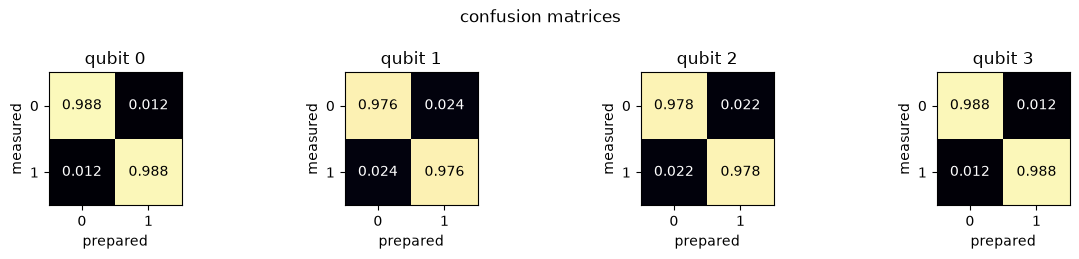

In [2]:
mit = ReadoutMitigator(ex, n_qubits=n, shots=2**16)
print("per-qubit readout error rates from the in-loop calibration pair:")
for q in range(n):
    print(f"  qubit {q}:  P(1|0) = {mit.e0[q]:.4f}   P(0|1) = {mit.e1[q]:.4f}")

fig, ax = plt.subplots(1, n, figsize=(3*n, 2.6))
for q in range(n):
    A = np.array([[1 - mit.e0[q], mit.e1[q]], [mit.e0[q], 1 - mit.e1[q]]])
    im = ax[q].imshow(A, cmap='magma', vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax[q].text(j, i, f'{A[i, j]:.3f}', ha='center', va='center',
                       color='w' if A[i, j] < .5 else 'k')
    ax[q].set_title(f'qubit {q}'); ax[q].set_xticks([0, 1]); ax[q].set_yticks([0, 1])
    ax[q].set_xlabel('prepared'); ax[q].set_ylabel('measured')
plt.suptitle('confusion matrices'); plt.tight_layout(); plt.show()

### **Gate Folding for ZNE**

ECR and CZ are self-inverse, so $G\to G^c$ scales the noise without changing the unitary. The Richardson coefficients amplify shot noise.

In [3]:
# --- measurement circuits, local copy -------------------------------------------------
# The logical circuits an estimator runs, before transpilation. Mirrors
# BatchedExpectation._dir_circuits (qconflib/gradients.py); each notebook that draws or
# counts circuits carries its own identical copy, so nothing here is imported across
# notebooks.
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qconflib import make_HEA, QFT_LNN, increment


def measurement_circuits(problem, method, depth=1, theta=None):
    """Order: one group per direction in problem.dims (SD -> m circuits, PO/FD -> 2),
    then the density circuit if the problem carries a potential.
    theta: bind these parameters; None leaves the ParameterVector symbolic."""
    n = problem.n
    pv = ParameterVector('t', n * depth)
    u = make_HEA(n, depth, pv).to_gate(label='U')
    circs = []
    for start, m, _ in problem.dims:
        if method == 'SD':
            for j in range(m):
                mm = m - j
                qc = QuantumCircuit(n, mm)
                qc.append(u, qc.qubits)
                for i in range(m - j - 1):
                    qc.cx(start + i + 1, start + i)
                qc.h(start + m - 1 - j)
                qc.measure(range(start, start + mm), range(mm))
                circs.append(qc)
        elif method == 'FD':
            qc = QuantumCircuit(n + 1, 1)
            qc.append(u, qc.qubits[:n])
            QFT_LNN(qc, m, start); qc.h(n)
            for idx in range(m):
                qc.cp((2 * np.pi / (2**m)) * (2**idx), n, start + m - 1 - idx)
            qc.h(n); qc.measure(n, 0)
            qc2 = QuantumCircuit(n, m)
            qc2.append(u, qc2.qubits)
            increment(qc2, m, start); qc2.h(start)
            qc2.measure(range(start, start + m), range(m))
            circs += [qc, qc2]
        elif method == 'PO':
            c1 = QuantumCircuit(n, 1)
            c1.append(u, c1.qubits)
            c1.h(start); c1.measure(start, 0)
            c2 = QuantumCircuit(n, m)
            c2.append(u, c2.qubits)
            increment(c2, m, start); c2.h(start)
            c2.measure(range(start, start + m), range(m))
            circs += [c1, c2]
        else:
            raise ValueError(f"unknown method {method}")
    if problem.ux is not None:
        qc = QuantumCircuit(n, n)
        qc.append(u, qc.qubits)
        qc.measure(range(n), range(n))
        circs.append(qc)
    if theta is not None:
        b = dict(zip(pv, theta))
        return [c.assign_parameters(b) for c in circs]
    return circs

from qconflib import fold_2q, richardson_coeffs

factors = (1, 3, 5)
coeffs = richardson_coeffs(factors)
print(f"fold factors {factors}")
print(f"Richardson coefficients {np.round(coeffs, 4)}   (sum {coeffs.sum():.3f})")
print(f"shot-noise amplification sqrt(sum c^2) = {np.sqrt((coeffs**2).sum()):.2f}x")

tqc = ex.transpile(measurement_circuits(prob, 'SD', depth=depth)[0])
for c in factors:
    folded = fold_2q(tqc, c)
    n2 = sum(1 for i in folded.data if i.operation.num_qubits == 2)
    print(f"  c = {c}: {folded.depth():>4} depth, {n2:>4} two-qubit gates")

fold factors (1, 3, 5)
Richardson coefficients [ 1.875 -1.25   0.375]   (sum 1.000)
shot-noise amplification sqrt(sum c^2) = 2.28x
  c = 1:   27 depth,    9 two-qubit gates
  c = 3:   41 depth,   27 two-qubit gates
  c = 5:   55 depth,   45 two-qubit gates


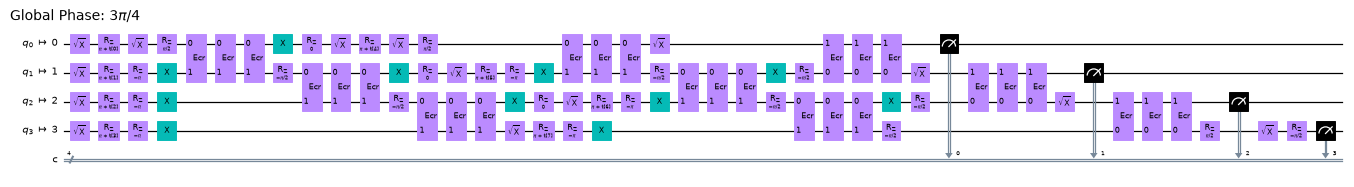

In [4]:
fold_2q(tqc, 3).draw('mpl', style='clifford', fold=-1, scale=0.45)

### **Mitigation at a Fixed Parameter Point**

In [5]:
from qconflib import statevector

rng = np.random.default_rng(3)
P = n * depth
th = rng.uniform(-np.pi, np.pi, P)
psi = statevector(th, n, depth)
exact = float(psi @ prob.M @ psi)
shots = 2**16

rows = []
bx = BatchedExpectation(prob, 'SD', depth, ex)
rows.append(('no mitigation', bx.value(th, shots)))

bx_ro = BatchedExpectation(prob, 'SD', depth, ex)
bx_ro.enable_readout_mitigation(cal_shots=2**16)
rows.append(('+ readout', bx_ro.value(th, shots)))

bx_z = BatchedExpectation(prob, 'SD', depth, ex)
bx_z.enable_readout_mitigation(cal_shots=2**16)
bx_z.enable_zne(factors)
rows.append(('+ readout + ZNE', bx_z.value(th, shots)))

print(f"exact <H> at this theta = {exact:.5f}\n")
b0 = abs(rows[0][1] - exact)
for name, v in rows:
    b = abs(v - exact)
    print(f"  {name:<18} {v:.5f}   bias {b:.5f}   ({100*(1-b/b0):5.1f}% of the bias removed)")

exact <H> at this theta = 2.03615

  no mitigation      2.04153   bias 0.00539   (  0.0% of the bias removed)
  + readout          2.04207   bias 0.00592   ( -9.9% of the bias removed)
  + readout + ZNE    2.04395   bias 0.00780   (-44.8% of the bias removed)


### **Mitigation Through Training**

In [6]:
from qconflib import solve
import time

ladder = {}
for name, mitigate in [('raw', None), ('+RO', ['readout']), ('+RO+ZNE', ['readout', 'zne'])]:
    t0 = time.perf_counter()
    ladder[name] = solve(prob, method='SD', depth=depth, shots=2**13, seed=111,
                         stages=((60, 2**13),), screen=6, noise_from='sherbrooke',
                         mitigate=mitigate)
    print(f"{name:<8} trace {ladder[name]['trace']:.4f}   "
          f"energy {ladder[name]['energy']:.5f} (exact {prob.lam_min:.5f})   "
          f"[{time.perf_counter()-t0:.0f} s]")

raw      trace 0.1128   energy 0.04567 (exact 0.03405)   [30 s]


[QConfLib] readout mitigation on: e0=[0.0113 0.0244 0.0215 0.0121] e1=[0.0115 0.0248 0.0218 0.0126]


+RO      trace 0.1064   energy 0.04443 (exact 0.03405)   [32 s]


[QConfLib] readout mitigation on: e0=[0.0113 0.0244 0.0215 0.0121] e1=[0.0115 0.0248 0.0218 0.0126]


[QConfLib] ZNE on: fold factors (1, 3, 5), Richardson coeffs [ 1.875 -1.25   0.375] (3x circuits)


+RO+ZNE  trace 0.1491   energy 0.04810 (exact 0.03405)   [40 s]


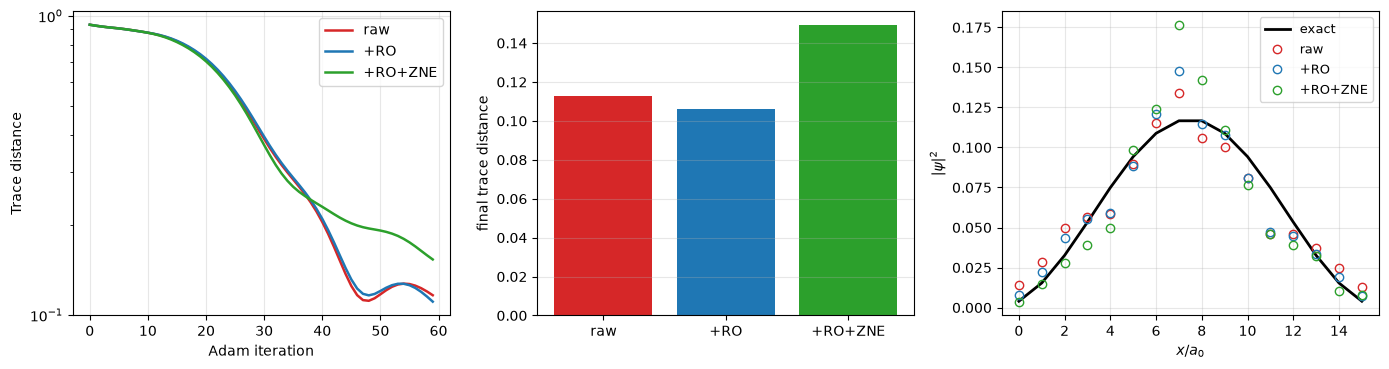

In [7]:
x = np.arange(2**n)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
cols = {'raw': '#d62728', '+RO': '#1f77b4', '+RO+ZNE': '#2ca02c'}
for name, c in cols.items():
    ax[0].semilogy([h[2] for h in ladder[name]['history']], color=c, lw=1.8, label=name)
ax[0].set_xlabel('Adam iteration'); ax[0].set_ylabel('Trace distance')
ax[0].grid(alpha=.3); ax[0].legend()

ax[1].bar(range(3), [ladder[k]['trace'] for k in cols], color=list(cols.values()))
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(list(cols))
ax[1].set_ylabel('final trace distance'); ax[1].grid(alpha=.3, axis='y')

ax[2].plot(x, np.abs(prob.ground)**2, 'k-', lw=2, label='exact')
for name, c in cols.items():
    ax[2].plot(x, ladder[name]['rho'], 'o', color=c, mfc='none', label=name)
ax[2].set_xlabel(r'$x/a_0$'); ax[2].set_ylabel(r'$|\psi|^2$')
ax[2].grid(alpha=.3); ax[2].legend(fontsize=9)
plt.tight_layout(); plt.show()

### **Production Ladder**

$N=32$, depth 4, 300 iterations, $2^{20}$ shots, changing only the mitigation setting.

In [8]:
import json, os
D = os.path.join('paper', 'data', 'prod')
tags = [('shot noise only', 'r_1d_N32', 'SD'),
        ('+ gate noise', 'r_1d_N32_noisy', 'SD'),
        ('+ readout', 'r_1d_N32_noisy_mitRO', 'SD'),
        ('+ readout + ZNE', 'r_1d_N32_noisy_mitROZNE', 'SD')]
vals = []
for label, stem, m in tags:
    meta = json.load(open(f'{D}/{stem}_meta.json'))
    vals.append((label, meta['terminal'][m]['trace']))
    print(f"  {label:<18} trace {vals[-1][1]:.4f}")
pen = vals[1][1] / vals[0][1]
rec = (vals[1][1] - vals[2][1]) / (vals[1][1] - vals[0][1])
print(f"\ngate-noise penalty       {pen:.1f}x")
print(f"recovered by readout     {100*rec:.0f}% of the penalty")
print(f"ZNE on top               {vals[3][1]:.4f}  ({'better' if vals[3][1] < vals[2][1] else 'worse'} than readout alone)")

  shot noise only    trace 0.0097
  + gate noise       trace 0.0565
  + readout          trace 0.0346
  + readout + ZNE    trace 0.0388

gate-noise penalty       5.8x
recovered by readout     47% of the penalty
ZNE on top               0.0388  (worse than readout alone)


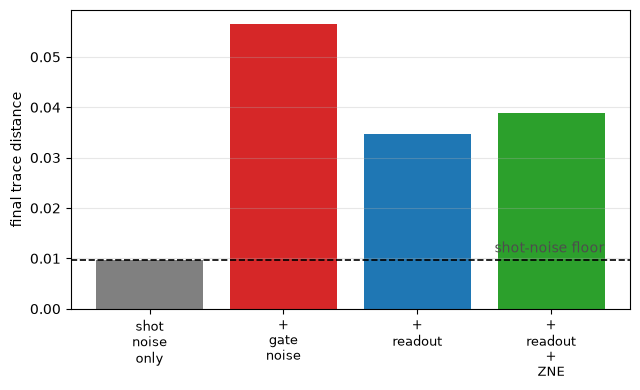

In [9]:
plt.figure(figsize=(6.5, 4))
plt.bar(range(len(vals)), [v for _, v in vals],
        color=['0.5', '#d62728', '#1f77b4', '#2ca02c'])
plt.axhline(vals[0][1], color='k', ls='--', lw=1.2)
plt.text(3.4, vals[0][1]*1.15, 'shot-noise floor', ha='right', color='0.3')
plt.xticks(range(len(vals)), [l.replace(' ', '\n') for l, _ in vals], fontsize=9)
plt.ylabel('final trace distance'); plt.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()